In [75]:
%pip install nltk --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [102]:
%pip install wordcloud --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# 1-IMPORTATION DES BIBLIOTHÈQUES 

In [ ]:

import os, re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from collections import Counter
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


[nltk_data] Downloading package punkt_tab to /home/hajar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/hajar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/hajar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/hajar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/hajar/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [77]:
#import datasets
df_fakenewsnet_buzzfeed_fake = pd.read_csv("/home/hajar/Downloads/archive/BuzzFeed_fake_news_content.csv")
df_fakenewsnet_buzzfeed_true = pd.read_csv("/home/hajar/Downloads/archive/BuzzFeed_real_news_content.csv")
df_fakenewsnet_politifact_fake = pd.read_csv("/home/hajar/Downloads/archive/PolitiFact_fake_news_content.csv")
df_fakenewsnet_politifact_true = pd.read_csv("/home/hajar/Downloads/archive/PolitiFact_real_news_content.csv")

In [78]:
print("Shape du dataset df_fakenewsnet_buzzfeed_fake  :", df_fakenewsnet_buzzfeed_fake .shape)

Shape du dataset df_fakenewsnet_buzzfeed_fake  : (91, 12)


In [79]:
df_fakenewsnet_buzzfeed_fake.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Fake_1-Webpage,Proof The Mainstream Media Is Manipulating The...,I woke up this morning to find a variation of ...,http://www.addictinginfo.org/2016/09/19/proof-...,http://addictinginfo.addictinginfoent.netdna-c...,Wendy Gittleson,http://www.addictinginfo.org,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://addictin...",http://addictinginfo.com/2016/09/19/proof-the-...,"{""publisher"": ""Addicting Info | The Knowledge ..."
1,Fake_10-Webpage,Charity: Clinton Foundation Distributed “Water...,Former President Bill Clinton and his Clinton ...,http://eaglerising.com/36899/charity-clinton-f...,http://eaglerising.com/wp-content/uploads/2016...,View All Posts,http://eaglerising.com,{'$date': 1474416521000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36899/charity-clinton-f...,"{""description"": ""The possibility that CHAI dis..."
2,Fake_11-Webpage,A Hillary Clinton Administration May be Entire...,After collapsing just before trying to step in...,http://eaglerising.com/36880/a-hillary-clinton...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Tony Elliott",http://eaglerising.com,{'$date': 1474416638000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36880/a-hillary-clinton...,"{""description"": ""Hillary Clinton may be the fi..."
3,Fake_12-Webpage,Trump’s Latest Campaign Promise May Be His Mos...,"Donald Trump is, well, deplorable. He’s sugges...",http://www.addictinginfo.org/2016/09/19/trumps...,http://addictinginfo.addictinginfoent.netdna-c...,John Prager,http://www.addictinginfo.org,{'$date': 1474243200000},NaN,"http://i.imgur.com/JeqZLhj.png,http://2.gravat...",http://addictinginfo.com/2016/09/19/trumps-lat...,"{""publisher"": ""Addicting Info | The Knowledge ..."
4,Fake_13-Webpage,Website is Down For Maintenance,Website is Down For Maintenance,http://www.proudcons.com/clinton-foundation-ca...,NaN,NaN,http://www.proudcons.com,NaN,NaN,NaN,NaN,"{""og"": {""url"": ""http://www.proudcons.com"", ""ty..."


In [80]:
print("Shape du dataset df_fakenewsnet_buzzfeed_true  :", df_fakenewsnet_buzzfeed_true .shape)

Shape du dataset df_fakenewsnet_buzzfeed_true  : (91, 12)


In [81]:
df_fakenewsnet_buzzfeed_true.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Real_1-Webpage,Another Terrorist Attack in NYC…Why Are we STI...,"On Saturday, September 17 at 8:30 pm EST, an e...",http://eaglerising.com/36942/another-terrorist...,http://eaglerising.com/wp-content/uploads/2016...,"View All Posts,Leonora Cravotta",http://eaglerising.com,{'$date': 1474528230000},NaN,http://constitution.com/wp-content/uploads/201...,http://eaglerising.com/36942/another-terrorist...,"{""description"": ""\u201cWe believe at this poin..."
1,Real_10-Webpage,"Donald Trump: Drugs a 'Very, Very Big Factor' ...",Less than a day after protests over the police...,http://abcn.ws/2d4lNn9,http://a.abcnews.com/images/Politics/AP_donald...,"More Candace,Adam Kelsey,Abc News,More Adam",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/donald-trump-dr...,"{""fb_title"": ""Trump: Drugs a 'Very, Very Big F..."
2,Real_11-Webpage,"Obama To UN: ‘Giving Up Liberty, Enhances Secu...","Obama To UN: ‘Giving Up Liberty, Enhances Secu...",http://rightwingnews.com/barack-obama/obama-un...,http://rightwingnews.com/wp-content/uploads/20...,Cassy Fiano,http://rightwingnews.com,{'$date': 1474476044000},https://www.youtube.com/embed/ji6pl5Vwrvk,http://rightwingnews.com/wp-content/uploads/20...,http://rightwingnews.com/barack-obama/obama-un...,"{""googlebot"": ""noimageindex"", ""og"": {""site_nam..."
3,Real_12-Webpage,Trump vs. Clinton: A Fundamental Clash over Ho...,Getty Images Wealth Of Nations Trump vs. Clint...,http://politi.co/2de2qs0,http://static.politico.com/e9/11/6144cdc24e319...,"Jack Shafer,Erick Trickey,Zachary Karabell",http://politi.co,{'$date': 1474974420000},NaN,https://static.politico.com/dims4/default/8a1c...,http://www.politico.com/magazine/story/2016/09...,"{""description"": ""He sees it as zero-sum. She b..."
4,Real_13-Webpage,"President Obama Vetoes 9/11 Victims Bill, Sett...",President Obama today vetoed a bill that would...,http://abcn.ws/2dh2NFs,http://a.abcnews.com/images/US/AP_Obama_BM_201...,"John Parkinson,More John,Abc News,More Alexander",http://abcn.ws,NaN,NaN,http://www.googleadservices.com/pagead/convers...,http://abcnews.go.com/Politics/president-obama...,"{""fb_title"": ""President Obama Vetoes 9/11 Vict..."


In [82]:
print("Shape du dataset df_fakenewsnet_politifact_fake  :", df_fakenewsnet_politifact_fake.shape)

Shape du dataset df_fakenewsnet_politifact_fake  : (120, 12)


In [83]:
df_fakenewsnet_politifact_fake.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Real_1-Webpage,Trump Just Insulted Millions Who Lost Everythi...,16.8k SHARES SHARE THIS STORY\n\nHillary Clint...,http://occupydemocrats.com/2016/09/27/trump-ju...,http://occupydemocrats.com/wp-content/uploads/...,"Brett Bose,Grant Stern,Steve Bernstein,Natalie...",http://occupydemocrats.com,{'$date': 1474934400000},NaN,http://occupydemocrats.com/wp-content/uploads/...,http://occupydemocrats.com/2016/09/27/trump-ju...,"{""generator"": ""Powered by Visual Composer - dr..."
1,Real_10-Webpage,Famous dog killed in spot she waited a year fo...,Famous dog killed in spot she waited a year fo...,http://rightwingnews.com/top-news/famous-dog-k...,http://rightwingnews.com/wp-content/uploads/20...,NaN,http://rightwingnews.com,{'$date': 1474948336000},NaN,http://rightwingnews.com/wp-content/uploads/20...,http://rightwingnews.com/top-news/famous-dog-k...,"{""googlebot"": ""noimageindex"", ""og"": {""site_nam..."
2,Real_100-Webpage,House oversight panel votes Clinton IT chief i...,Story highlights The House Oversight panel vot...,http://cnn.it/2deaH2d,http://i2.cdn.cnn.com/cnnnext/dam/assets/16091...,"Tom Lobianco,Deirdre Walsh",http://cnn.it,NaN,NaN,http://i2.cdn.cnn.com/cnnnext/dam/assets/17050...,http://www.cnn.com/2016/09/22/politics/bryan-p...,"{""description"": ""Members of the House Oversigh..."
3,Real_101-Webpage,America Just Tragically Lost A Country Music I...,We are absolutely heartbroken to hear about th...,http://newsbake.com/entertainment-news/music-e...,http://newsbake.com/wp-content/uploads/2016/05...,Nancy Wells,http://newsbake.com,{'$date': 1474898600000},https://www.youtube.com/embed/8ozTJcu-_BU,http://0.gravatar.com/avatar/0d702c6042933cd78...,http://newsbake.com/entertainment-news/music-e...,"{""shareaholic"": {""site_name"": ""NewsBake"", ""lan..."
4,Real_102-Webpage,Monuments to the Battle for the New South,"Nine years ago, a driver lost control of his p...",http://politi.co/2dd9U1x,http://static.politico.com/25/ed/85332de14c45b...,"Jack Shafer,Lisa Rab",http://politi.co,{'$date': 1473941820000},NaN,http://static.politico.com/25/ed/85332de14c45b...,http://www.politico.com/magazine/story/2016/09...,"{""description"": ""Virginia, increasingly divers..."


In [84]:
print("Shape du dataset df_fakenewsnet_politifact_true  :", df_fakenewsnet_politifact_true .shape)

Shape du dataset df_fakenewsnet_politifact_true  : (120, 12)


In [85]:
df_fakenewsnet_politifact_true.head()

,id,title,text,url,top_img,authors,source,publish_date,movies,images,canonical_link,meta_data
0,Real_1-Webpage,Trump Just Insulted Millions Who Lost Everythi...,16.8k SHARES SHARE THIS STORY\n\nHillary Clint...,http://occupydemocrats.com/2016/09/27/trump-ju...,http://occupydemocrats.com/wp-content/uploads/...,"Brett Bose,Grant Stern,Steve Bernstein,Natalie...",http://occupydemocrats.com,{'$date': 1474934400000},NaN,http://occupydemocrats.com/wp-content/uploads/...,http://occupydemocrats.com/2016/09/27/trump-ju...,"{""generator"": ""Powered by Visual Composer - dr..."
1,Real_10-Webpage,Famous dog killed in spot she waited a year fo...,Famous dog killed in spot she waited a year fo...,http://rightwingnews.com/top-news/famous-dog-k...,http://rightwingnews.com/wp-content/uploads/20...,NaN,http://rightwingnews.com,{'$date': 1474948336000},NaN,http://rightwingnews.com/wp-content/uploads/20...,http://rightwingnews.com/top-news/famous-dog-k...,"{""googlebot"": ""noimageindex"", ""og"": {""site_nam..."
2,Real_100-Webpage,House oversight panel votes Clinton IT chief i...,Story highlights The House Oversight panel vot...,http://cnn.it/2deaH2d,http://i2.cdn.cnn.com/cnnnext/dam/assets/16091...,"Tom Lobianco,Deirdre Walsh",http://cnn.it,NaN,NaN,http://i2.cdn.cnn.com/cnnnext/dam/assets/17050...,http://www.cnn.com/2016/09/22/politics/bryan-p...,"{""description"": ""Members of the House Oversigh..."
3,Real_101-Webpage,America Just Tragically Lost A Country Music I...,We are absolutely heartbroken to hear about th...,http://newsbake.com/entertainment-news/music-e...,http://newsbake.com/wp-content/uploads/2016/05...,Nancy Wells,http://newsbake.com,{'$date': 1474898600000},https://www.youtube.com/embed/8ozTJcu-_BU,http://0.gravatar.com/avatar/0d702c6042933cd78...,http://newsbake.com/entertainment-news/music-e...,"{""shareaholic"": {""site_name"": ""NewsBake"", ""lan..."
4,Real_102-Webpage,Monuments to the Battle for the New South,"Nine years ago, a driver lost control of his p...",http://politi.co/2dd9U1x,http://static.politico.com/25/ed/85332de14c45b...,"Jack Shafer,Lisa Rab",http://politi.co,{'$date': 1473941820000},NaN,http://static.politico.com/25/ed/85332de14c45b...,http://www.politico.com/magazine/story/2016/09...,"{""description"": ""Virginia, increasingly divers..."


FakeNewsNet contient 4 fichiers CSV :<br>
Titres réels et faux issus de PolitiFact (politique) et GossipCop (célébrités).<br>
On les fusionne en un seul DataFrame avec une colonne label.

# 2-Nettoyage des données
 On garde uniquement les colonnes utiles ,et on traite les valeurs manquantes et les doublons pour éviter le biais.

In [86]:

# remove unneeded columns
df_fakenewsnet_buzzfeed_fake.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)
df_fakenewsnet_buzzfeed_true.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)
df_fakenewsnet_politifact_fake.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)
df_fakenewsnet_politifact_true.drop(["id", "url", "top_img", "authors", "source", "publish_date", "movies", "images", "canonical_link", "meta_data"], axis=1, inplace=True)

In [87]:
# Create new 'label' column
df_fakenewsnet_buzzfeed_fake["label"] = 0
df_fakenewsnet_buzzfeed_true["label"] = 1
df_fakenewsnet_politifact_fake["label"] = 0
df_fakenewsnet_politifact_true["label"] = 1

La colonne label est binaire : 1 = fake, 0 = real — c'est la cible que le modèle devra prédire.

In [88]:
# Create new 'statement' column
df_fakenewsnet_buzzfeed_fake["statement"] = df_fakenewsnet_buzzfeed_fake["title"] + " " + df_fakenewsnet_buzzfeed_fake["text"]
df_fakenewsnet_buzzfeed_true["statement"] = df_fakenewsnet_buzzfeed_true["title"] + " " + df_fakenewsnet_buzzfeed_true["text"]
df_fakenewsnet_politifact_fake["statement"] = df_fakenewsnet_politifact_fake["title"] + " " + df_fakenewsnet_politifact_fake["text"]
df_fakenewsnet_politifact_true["statement"] = df_fakenewsnet_politifact_true["title"] + " " + df_fakenewsnet_politifact_true["text"]

In [89]:
# Combine the modified datasets
df_fakenewsnet_combined = pd.concat([df_fakenewsnet_buzzfeed_fake,df_fakenewsnet_buzzfeed_true, df_fakenewsnet_politifact_fake, df_fakenewsnet_politifact_true],axis=0).sample(frac = 1, random_state = 42).reset_index(drop = True)

On combine 4 sources (PolitiFact + GossipCop, fake + real) pour avoir un dataset diversifié couvrant à la fois la politique et la culture populaire.

In [90]:
#Shape du dataset complet
print("Shape du dataset complet :", df_fakenewsnet_combined.shape)

Shape du dataset complet : (422, 4)


In [91]:
# remove title and text column from combined dataset
df_fakenewsnet_combined.drop(["title", "text"], axis=1, inplace=True)

print(df_fakenewsnet_combined.head())

   label                                          statement
0      1  Kaine visits site of Orlando mass shooting Tim...
1      1  Christie among the most unpopular governors in...
2      1  McAuliffe hangs with Willie Nelson -- and his ...
3      1  Trump Gets ANNIHILATED On Twitter After He Pre...
4      1  BREAKING: Hollywood Legend Just Died Of Terrib...


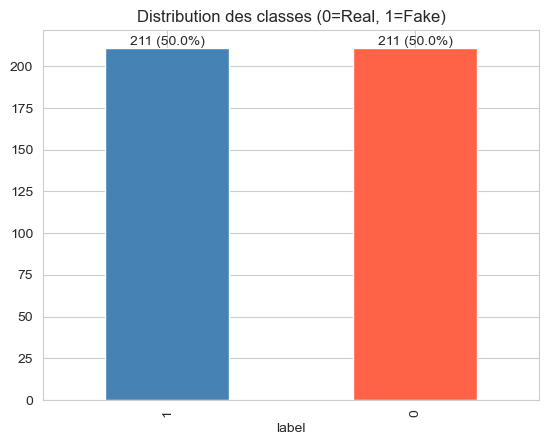

In [92]:
counts = df_fakenewsnet_combined['label'].value_counts()
percent = counts / counts.sum() * 100

ax = counts.plot(kind='bar', color=['steelblue','tomato'])
for i, (v, p) in enumerate(zip(counts, percent)):
    ax.text(i, v, f'{v} ({p:.1f}%)', ha='center', va='bottom')

plt.title('Distribution des classes (0=Real, 1=Fake)')
plt.show()

In [ ]:
# Check for duplicates
df_fakenewsnet_combined.duplicated().sum()

19

In [ ]:
# Remove duplicates
df_fakenewsnet_combined.drop_duplicates(inplace=True)

In [95]:
df_fakenewsnet_combined.duplicated().sum()

0

In [96]:
df_fakenewsnet_combined

,label,statement
0,1,Kaine visits site of Orlando mass shooting Tim...
1,1,Christie among the most unpopular governors in...
2,1,McAuliffe hangs with Willie Nelson -- and his ...
3,1,Trump Gets ANNIHILATED On Twitter After He Pre...
4,1,BREAKING: Hollywood Legend Just Died Of Terrib...
...,...,...
417,0,New Clinton Foundation SCANDAL Just Broke – Th...
418,1,Dem congressman to IRS: Audit the Trump Founda...
419,0,Hillary Clinton leads Donald Trump by 6 points...
420,1,KISS’ Gene Simmons: “You Want to Win the War o...


In [ ]:
# Check for missing values
df_fakenewsnet_combined.isna().sum()

label        0
statement    0
dtype: int64

# 3-Prétraitement NLP 
Mise en minuscules <br>
Suppression URLs, HTML, ponctuation, chiffres<br>
Tokenisation<br>
Suppression des stopwords<br>
Lemmatisation<br>

In [98]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # URLs
    text = re.sub(r'<.*?>', ' ', text)                # HTML
    text = re.sub(r'[^a-z\s]', ' ', text)            # ponctuation/chiffres
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_fakenewsnet_combined['clean'] = df_fakenewsnet_combined['statement'].apply(clean_text)
df_fakenewsnet_combined[['statement','clean']].head(3)
print('Shape après NLP :', df_fakenewsnet_combined.shape)
df_fakenewsnet_combined[['clean','label']].head()

Shape après NLP : (403, 3)


,clean,label
0,kaine visit site orlando mass shooting tim kai...,1
1,christie among unpopular governor country poll...,1
2,mcauliffe hang willie nelson weed story highli...,1
3,trump get annihilated twitter pretend trash po...,1
4,breaking hollywood legend died terrible diseas...,1


In [99]:
for i in range(5):
    print(df_fakenewsnet_combined['clean'][i])
    print('---')

kaine visit site orlando mass shooting tim kaine visit pulse night club orlando monday evening burgess everett politico kaine visit site orlando mass shooting orlando tim kaine visited pulse night club monday evening site gunman omar mateen killed people june virginia senator laid flower memorial surrounding club attended alongside former rep gabby giffords ariz injured mass shooting well giffords husband astronaut mark kelly sen bill nelson fla story continued thing painful weird thing say always hoped virginia tech would worst one ever kaine told reporter quiet minute visit site bad hoped nothing would ever eclipse life got work kaine virginia governor shooter killed people university later monday kaine giffords kelly scheduled attend presidential debate watch party lgbt activist orlando kaine running mate hillary clinton visited pulse july author
---
christie among unpopular governor country poll find gov chris christie greets resident gathering camden photo mel evans christie among

# 4-EDA

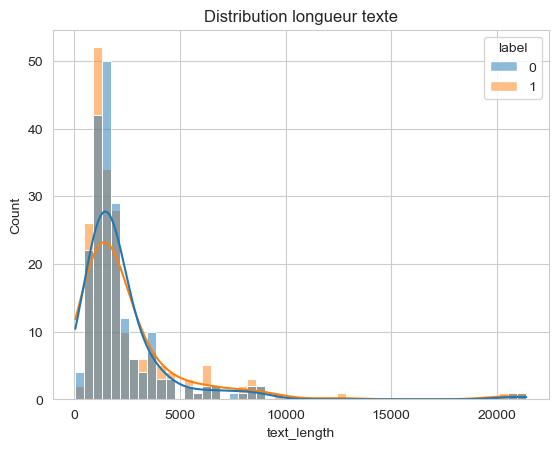

In [100]:
# Text length
df_fakenewsnet_combined['text_length'] = df_fakenewsnet_combined['clean'].astype(str).apply(len)

sns.histplot(data=df_fakenewsnet_combined, x='text_length', hue='label', bins=50, kde=True)
plt.title("Distribution longueur texte")
plt.show()

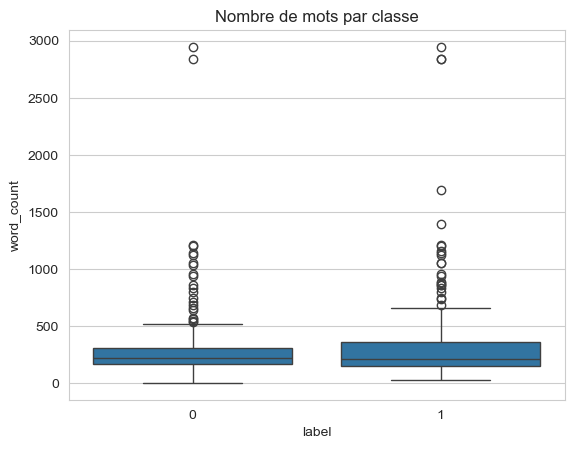

In [101]:
# Word count
df_fakenewsnet_combined['word_count'] = df_fakenewsnet_combined['clean'].astype(str).apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df_fakenewsnet_combined)
plt.title("Nombre de mots par classe")
plt.show()

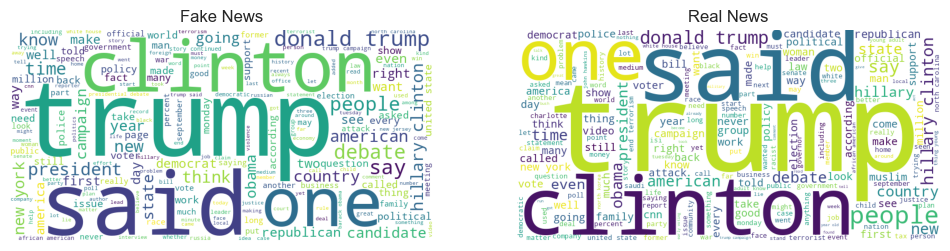

In [ ]:
# Top words

fake_text = " ".join(df_fakenewsnet_combined[df_fakenewsnet_combined['label']==1]['clean'])
real_text = " ".join(df_fakenewsnet_combined[df_fakenewsnet_combined['label']==0]['clean'])

wc_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
wc_real = WordCloud(width=800, height=400, background_color='white').generate(real_text)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(wc_fake)
plt.title("Fake News")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real)
plt.title("Real News")
plt.axis("off")

plt.show()

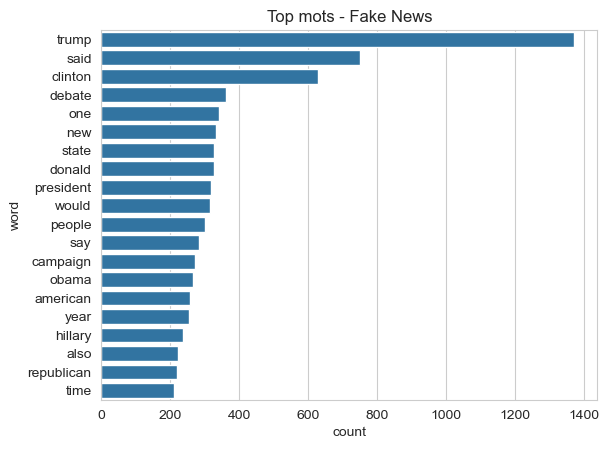

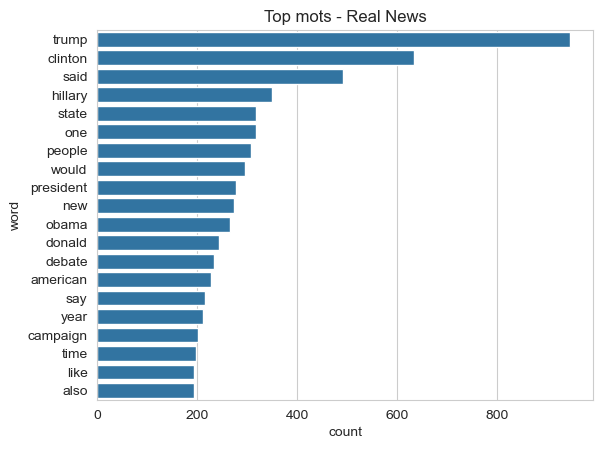

In [ ]:
# Top words (barplot)
def get_top_words(texts, n=20):
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

fake_words = get_top_words(df_fakenewsnet_combined[df_fakenewsnet_combined['label']==1]['clean'])
real_words = get_top_words(df_fakenewsnet_combined[df_fakenewsnet_combined['label']==0]['clean'])

fake_df = pd.DataFrame(fake_words, columns=['word','count'])
real_df = pd.DataFrame(real_words, columns=['word','count'])

sns.barplot(x='count', y='word', data=fake_df)
plt.title("Top mots - Fake News")
plt.show()

sns.barplot(x='count', y='word', data=real_df)
plt.title("Top mots - Real News")
plt.show()

# 5- TF_IDF + PCA

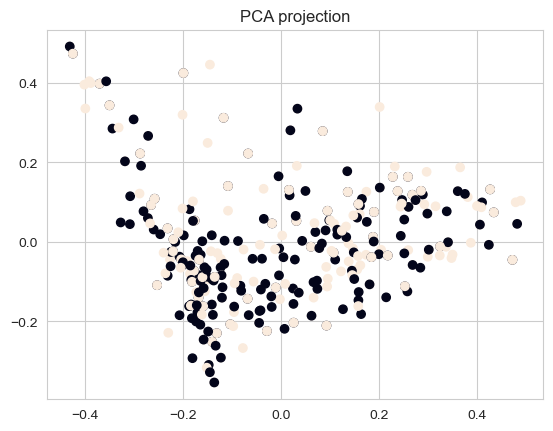

In [ ]:
tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(df_fakenewsnet_combined['clean'].astype(str))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=df_fakenewsnet_combined['label'])
plt.title("PCA projection")
plt.show()

on remarque que les classes ne sont pas parfaitement séparables, mais on peut voir une certaine tendance à la séparation.